## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
import requests


# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?latitude=43.254&longitude=-2.923&hourly=temperature_2m&timezone=Europe%2FBerlin"  # Aquí vienen el resto de los parámetros

def get_tiempo(url):
    response = requests.get(url)

    if response.status_code == 200:  # Código 200 indica una respuesta exitosa.
        data = response.json()  # Analizar la respuesta JSON.
        return data
    else:
        print("Error en la solicitud: ", response.status_code)

tiempo = get_tiempo(url)

In [3]:
dict_tiempo = {'Hora': tiempo["hourly"]["time"],
        'Temperatura':tiempo["hourly"]["temperature_2m"]}

In [4]:
df_tiempo = pd.DataFrame(dict_tiempo)

In [5]:
df_tiempo

,Hora,Temperatura
0,2025-11-20T00:00,11.3
1,2025-11-20T01:00,10.0
2,2025-11-20T02:00,9.3
3,2025-11-20T03:00,9.4
4,2025-11-20T04:00,9.0
...,...,...
163,2025-11-26T19:00,9.6
164,2025-11-26T20:00,9.5
165,2025-11-26T21:00,9.5
166,2025-11-26T22:00,9.5


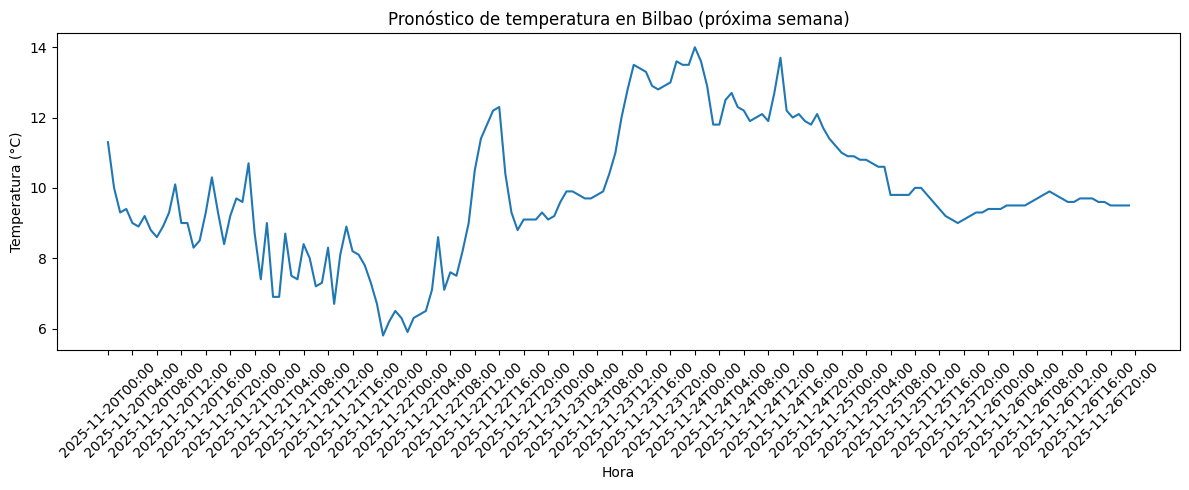

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df_tiempo["Hora"], df_tiempo["Temperatura"])
plt.title("Pronóstico de temperatura en Bilbao (próxima semana)")
plt.xlabel("Hora")
plt.ylabel("Temperatura (°C)")
plt.xticks(range(0, 170, 4), rotation=45)
plt.tight_layout()
plt.show()

In [7]:
fig = px.line(
    df_tiempo,
    x="Hora",
    y="Temperatura",
    title="Pronóstico de temperatura en Bilbao (próxima semana)",
    labels={
        "Hora": "Hora",
        "Temperatura": "Temperatura (°C)"
    }
)

fig.show()
